In [1]:
import math
import numpy as np
from pathlib import Path
import os
import re
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%config InlineBackend.figure_format = 'retina'

In [2]:
# GENERAL CONSTANTS
ta = 0.02 # 20 ms
kn = 5

# LINE PLOTS CONSTANTS
# desired line
Pix_line = 0.0
Piy_line = 0.0
Pfx_line = 1.0
Pfy_line = 1.0

n_max_line = [-1, -1, -1, -1, -1] # last trajectory point in the data

# ARC PLOTS CONSTANTS
Pix_arc = 0.0
Piy_arc = 0.0
Pcx_arc = 0.5
Pcy_arc = 0.0
alpha_arc = -np.pi

n_max_arc = [-1, -1, -1, -1, -1] # last trajectory point in the data

# PRETTY COLORS
plot_colors = ['mediumpurple', 'xkcd:dodger blue', 'yellowgreen', 'orange', 'xkcd:dull red', 'black'] # add more colors if more data
grid_color = 'lightgray'

# PATHS
im_dir = Path('../../Imagens')
im_dir.mkdir(parents = True, exist_ok = True)
data_dir = Path('Dados ktheta')

# Load data

In [3]:
all_data = {}

files = [f for f in os.listdir(data_dir) if f.endswith('.txt')]
# print(files_line)

pattern_line = re.compile(r'Line_ktheta_([+-]?\d+)')
pattern_arc = re.compile(r'Arc_ktheta_([+-]?\d+)')

for file in files:
    match_line = pattern_line.search(file)
    match_arc = pattern_arc.search(file)

    if match_line is not None:
        traj_type = 'Line'
        ktheta = float(match_line.group(1))
    elif match_arc is not None:
        traj_type = 'Arc'
        ktheta = float(match_arc.group(1))
    else:
        print(f"No match for {file}")
        continue
    
    print(file, ktheta)
    
    d = np.loadtxt(data_dir / file).T # t, v, omega, x, y, theta
    all_data.setdefault(traj_type, {})[ktheta] = d

Arc_ktheta_+010.txt 10.0
Arc_ktheta_+020.txt 20.0
Arc_ktheta_+050.txt 50.0
Arc_ktheta_+200.txt 200.0
Arc_ktheta_-020.txt -20.0
Line_ktheta_+010.txt 10.0
Line_ktheta_+020.txt 20.0
Line_ktheta_+050.txt 50.0
Line_ktheta_+200.txt 200.0
Line_ktheta_-020.txt -20.0


# Trajectory and error plots

In [4]:
def des_traj_line(Pix, Piy, Pfx, Pfy, point_num = 100):
    m = (Pfy - Piy)/(Pfx - Pix)
    b = Piy - m*Pix
    x = np.linspace(Pix, Pfx, point_num)
    y = m * x + b
    return x, y

def des_traj_arc(Pix, Piy, Pcx, Pcy, alpha, point_num = 100):
    r = np.sqrt((Piy - Pcy)**2 + (Pix - Pcx)**2)
    thetai = math.atan2(Piy - Pcy, Pix - Pcx)
    theta = np.linspace(thetai, thetai + alpha)
    x = r * np.cos(theta) + Pcx
    y = r * np.sin(theta) + Pcy
    return x, y

In [5]:
def error_line(x, y, theta, Pix, Piy, Pfx, Pfy):
    # direção desejada da linha
    theta_f = np.arctan2(Pfy - Piy, Pfx - Pix)

    # erro em direção
    e_theta = theta_f - theta
    e_theta = np.arctan2(np.sin(e_theta), np.cos(e_theta)) # normalizar para [-pi, pi]
    
    # v_if
    uifx = Pfx - Pix
    uify = Pfy - Piy

    norm_uif = np.sqrt(uifx**2 + uify**2)
    vifx = uifx / norm_uif
    vify = uify / norm_uif

    # uir
    uirx = x - Pix
    uiry = y - Piy

    # erro lateral
    ed = vifx * uiry - vify * uirx
    rmse = np.sqrt(np.sum(ed ** 2) / len(ed))

    return e_theta, ed, rmse


def error_arc(x, y, theta, Pix, Piy, Pcx, Pcy, alpha):
    # r (raio)
    r = np.sqrt((Piy - Pcy)**2 + (Pix - Pcx)**2)

    # d (distancia)
    ucrx = x - Pcx
    ucry = y - Pcy
    d = np.sqrt(ucrx**2 + ucry**2)

    # erro radial
    e_n = d - r
    rmse = np.sqrt(np.sum(e_n ** 2) / len(e_n))

    # v_t
    if alpha_arc >= 0:
        vtx = - ucry
        vty =   ucrx
    else:
        vtx =   ucry
        vty =  - ucrx

    theta_t = np.arctan2(vty, vtx)

    # erro em direção
    e_theta = theta_t - theta

    e_theta = np.arctan2(np.sin(e_theta), np.cos(e_theta))

    return e_theta, e_n, rmse

In [6]:
def find_n_min(x, y):
    # índices onde (x,y) muda em relação ao ponto anterior
    changes = np.where((x[1:] != x[:-1]) | (y[1:] != y[:-1]))[0] + 1
    
    if len(changes) == 0:
        return 0          # nunca se move
    if len(changes) == 1:
        return changes[0] # só há uma transição (comportamento antigo)
    
    return changes[1]     # segunda transição = início da trajetória real

Arc 10.0 (6, 328)
Arc 20.0 (6, 327)
Arc 50.0 (6, 396)
Arc 200.0 (6, 393)
Arc -20.0 (6, 298)
Line 10.0 (6, 442)
Line 20.0 (6, 417)
Line 50.0 (6, 339)
Line 200.0 (6, 324)
Line -20.0 (6, 326)


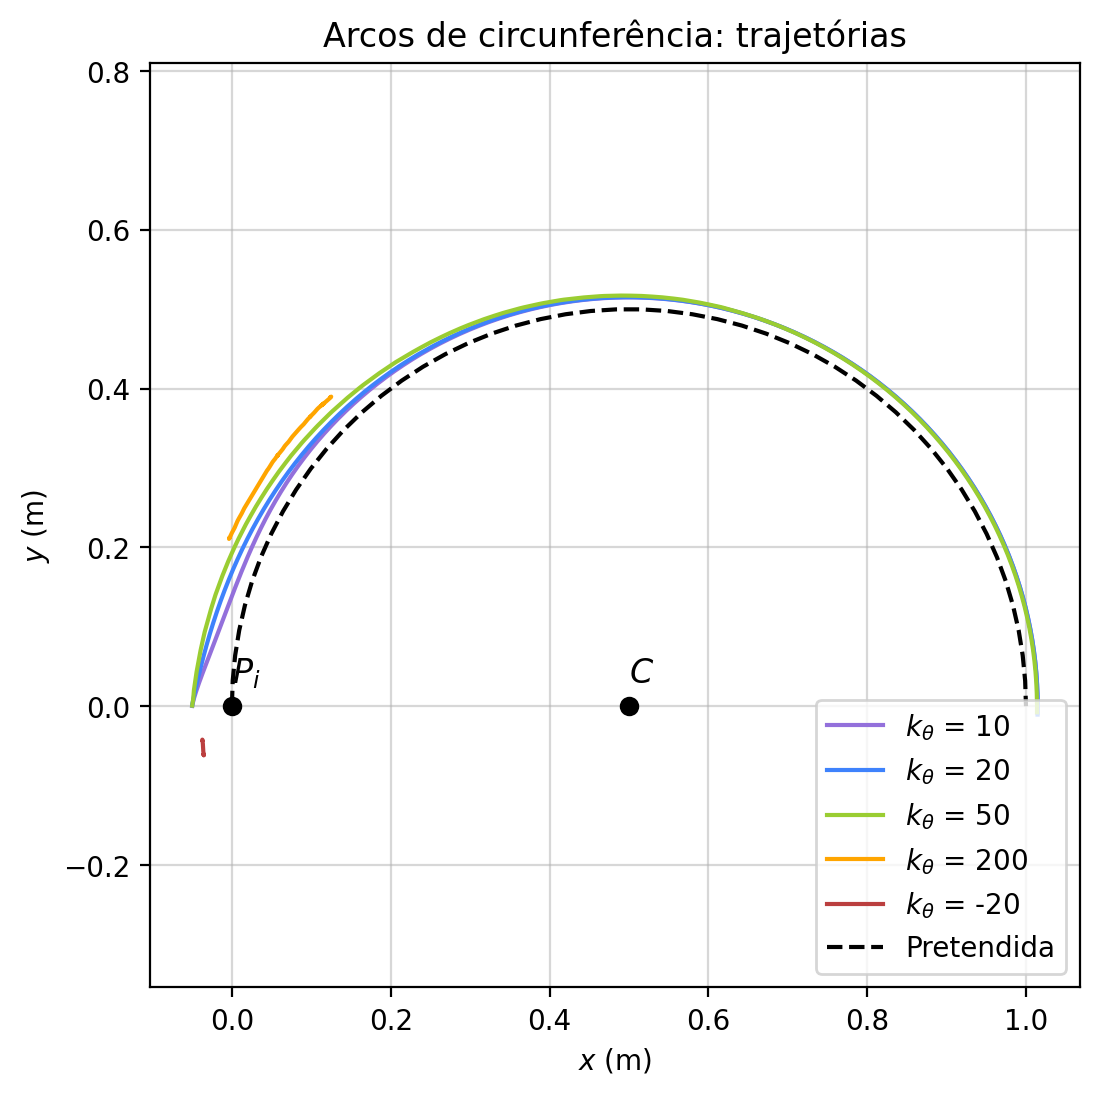

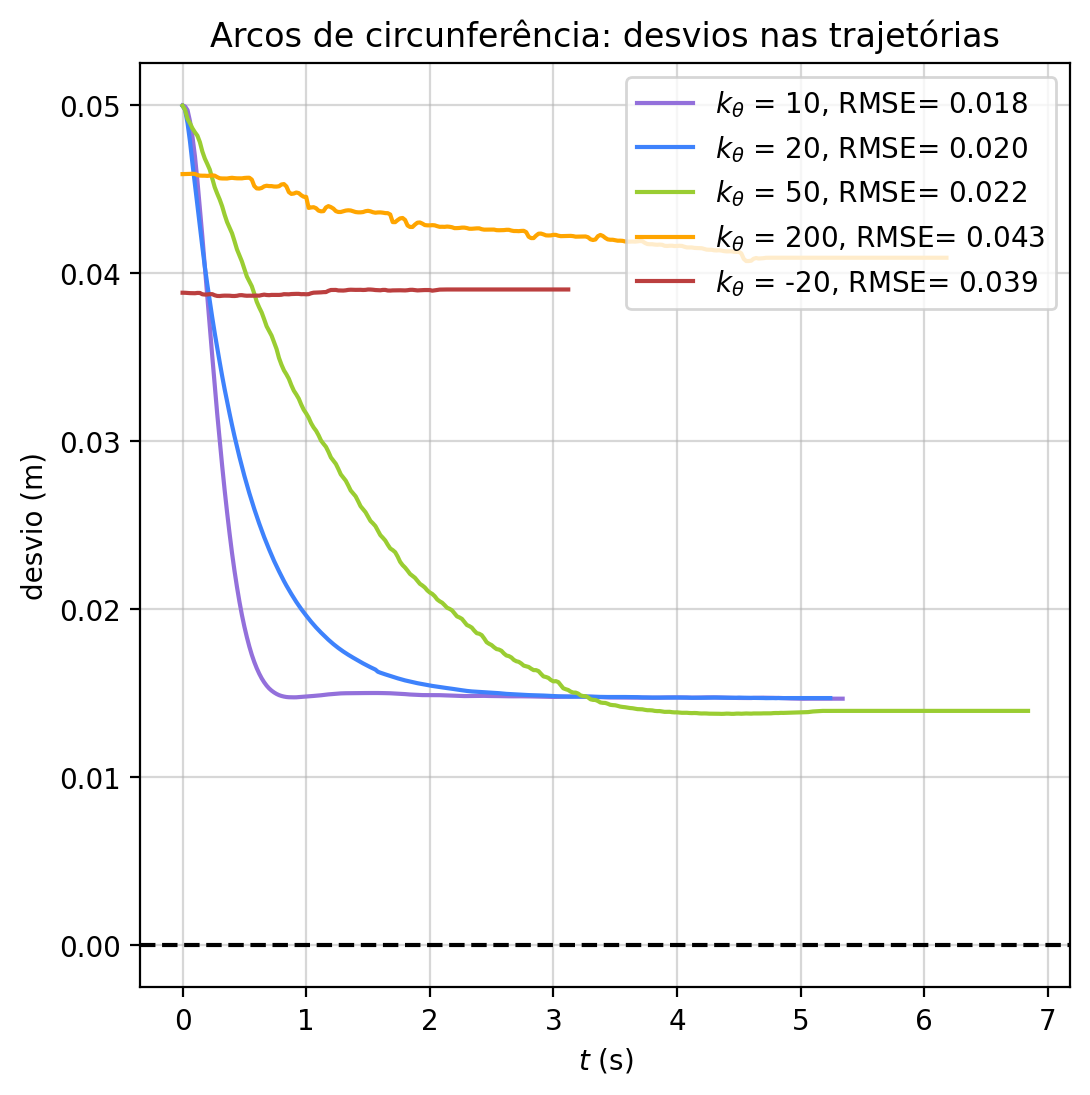

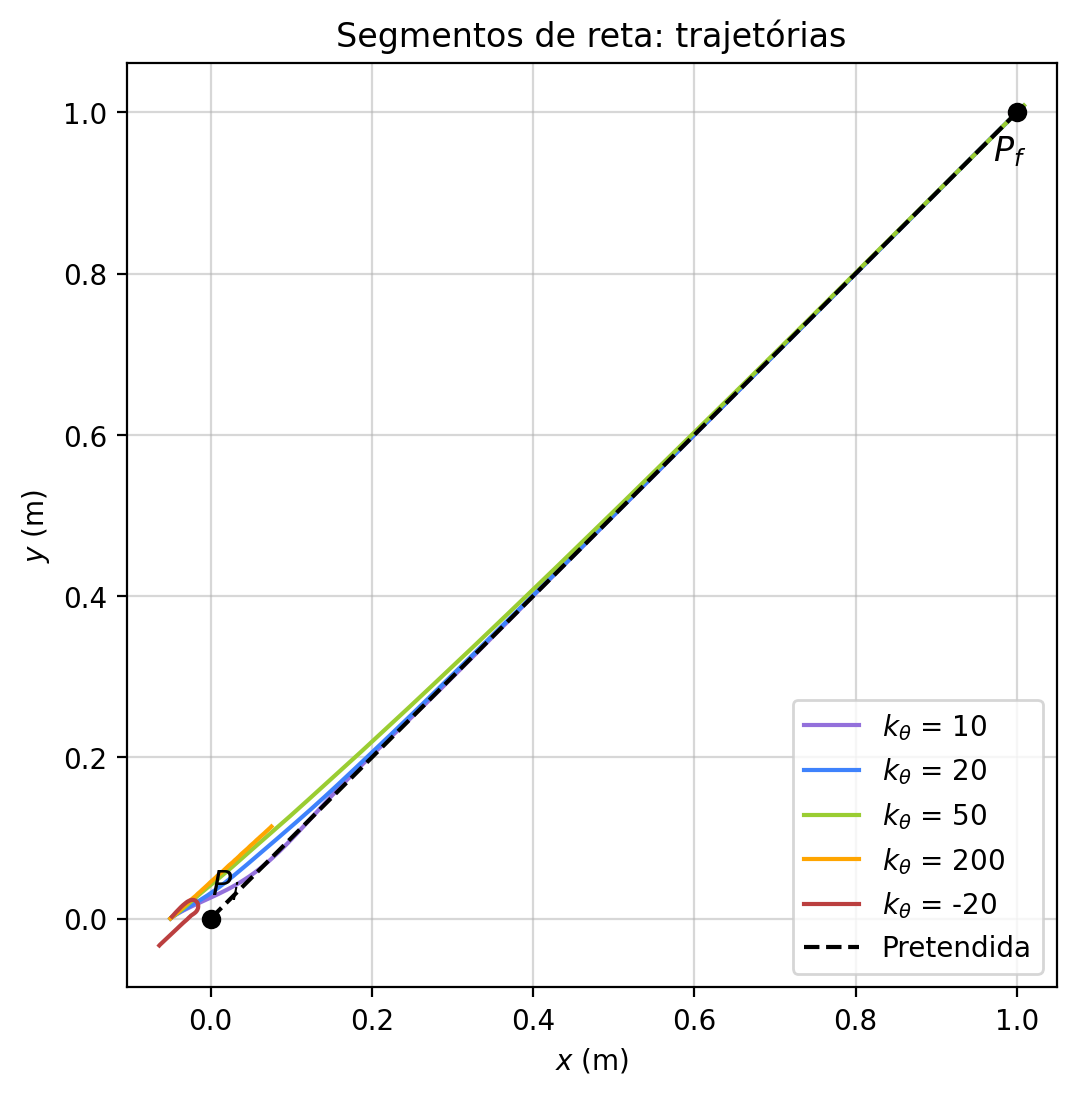

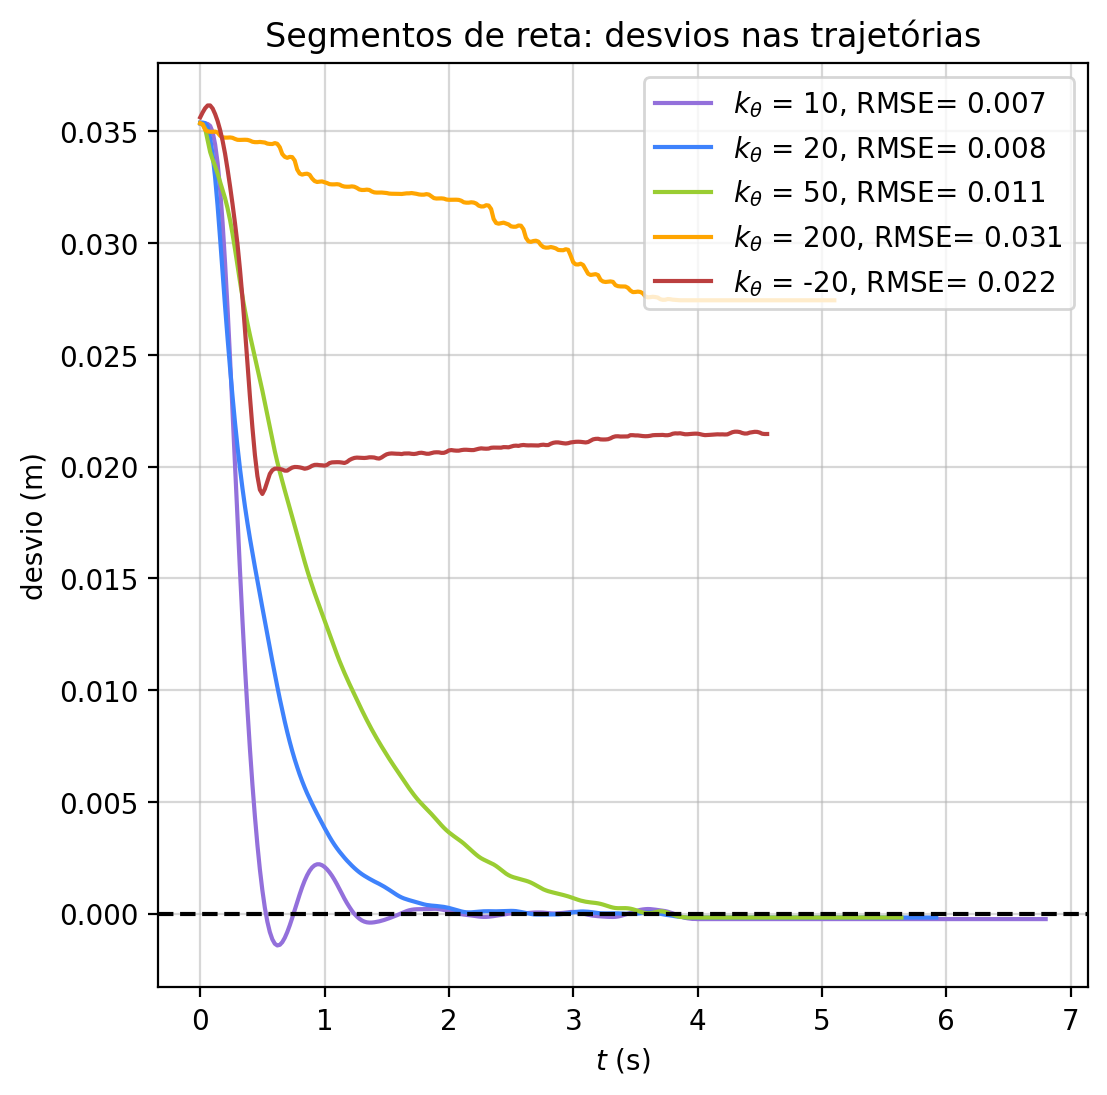

In [7]:
for traj_type, sub in all_data.items():
    if traj_type == 'Line':
        title = 'Segmentos de reta'
        traj_parms = Pix_line, Piy_line, Pfx_line, Pfy_line
        des_traj = des_traj_line
        error_f = error_line
        n_max = n_max_line
        
    elif traj_type == 'Arc':
        title = "Arcos de circunferência"
        traj_parms = Pix_arc, Piy_arc, Pcx_arc, Pcy_arc, alpha_arc
        des_traj = des_traj_arc
        error_f = error_arc
        n_max = n_max_arc
        
    else:
        print("Trajetória desconhecida")
        continue
        
    fig_traj, ax_traj = plt.subplots(figsize=(6,6))
    ax_traj.axis('equal')
    ax_traj.set_title(title + ': trajetórias')
    ax_traj.grid(grid_color, alpha = 0.5)
    ax_traj.set_xlabel(r'$x$ (m)')
    ax_traj.set_ylabel(r'$y$ (m)')
    
    fig_error, ax_error = plt.subplots(figsize=(6,6))
    ax_error.set_title(title + ': desvios nas trajetórias')
    ax_error.grid(grid_color, alpha = 0.5)
    ax_error.set_xlabel(r'$t$ (s)')
    ax_error.set_ylabel('desvio (m)')
    
    for i, (ktheta, data) in enumerate(sub.items()):
        print(traj_type, ktheta, data.shape) # t, v, omega, x, y, theta

        t = data[0]
        x = data[3]
        y = data[4]
        theta = data[5]

        n_min = find_n_min(x, y)
        data = data[:, n_min:n_max[i]]

        t = data[0] - data[0, 0]
        x = data[3]
        y = data[4]
        theta = data[5]

        # plot trajectory
        ax_traj.plot(x, y, label = fr'$k_θ$ = {ktheta:.0f}', color = plot_colors[i])

        e_theta, e_n, rmse = error_f(x, y, theta, *traj_parms)

        ax_error.plot(t, e_n, label = f'$k_θ$ = {ktheta:.0f}, RMSE= {rmse:.3f}', color = plot_colors[i])

    xd, yd = des_traj(*traj_parms)
    ax_traj.plot(xd, yd, '--', label = 'Pretendida', color = plot_colors[i + 1])
    ax_traj.legend(loc = 'lower right')

    ax_error.axhline(0, linestyle = '--', color = plot_colors[i + 1])
    ax_error.legend(loc = 'upper right')

    if traj_type == 'Line':
        ax_traj.plot(Pix_line, Piy_line, 'o', color='black')
        ax_traj.text(Pix_line, Piy_line + 0.03, r'$P_i$', size='large')
        ax_traj.plot(Pfx_line, Pfy_line, 'o', color='black')
        ax_traj.text(Pfx_line-0.03, Pfy_line - 0.06, r'$P_f$', size='large')

    elif traj_type == 'Arc':
        ax_traj.plot(Pcx_arc, Pcy_arc, 'o', color = 'black')
        ax_traj.text(Pcx_arc, Pcy_arc + 0.03, r'$C$', size='large')
        ax_traj.plot(Pix_arc, Piy_arc, 'o', color = 'black')
        ax_traj.text(Pix_arc, Piy_arc + 0.03, r'$P_i$', size = 'large')

    fig_traj.savefig(im_dir/f'traj_{title}_ktheta.png', dpi = 300, bbox_inches = 'tight')
    fig_error.savefig(im_dir/f'error_{title}_ktheta.png', dpi = 300, bbox_inches = 'tight')